In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv(
    "../data/processed/featured_uhi.csv"
)

df.head()

,LST,Latitude,Longitude,NDBI,NDVI,Green_Built_Ratio,Heat_Exposure_Index
0,43.919170,19.970832,75.438700,0.127207,0.162286,1.182783,5.586821
1,39.060455,19.729093,75.209548,-0.272423,0.570751,2.020910,-10.640952
2,40.231127,19.788775,75.225639,0.055877,0.099371,1.508423,2.248012
3,44.884761,19.960297,75.544582,0.121404,0.196037,1.491866,5.449194
4,48.502735,19.867709,75.486062,0.133151,0.165262,1.154459,6.458205


In [3]:
X = df[
    [
        "NDVI",
        "NDBI",
        "Latitude",
        "Longitude",
        "Green_Built_Ratio",
        "Heat_Exposure_Index"
    ]
]

y = df["LST"]

print(X.shape)
print(y.shape)

(5000, 6)
(5000,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4000, 6)
(1000, 6)


In [5]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [6]:
predictions = model.predict(
    X_test
)

predictions[:10]

array([46.26682724, 41.9530411 , 44.00255977, 43.14975411, 45.37820563,
       43.32116398, 45.15686154, 44.14232356, 40.76232687, 39.66434824])

In [7]:
mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = mse ** 0.5

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 1.86405700108254
RMSE: 2.510523843101338
R2  : 0.47570528986765737


In [8]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
0,46.834741,46.266827
1,40.032882,41.953041
2,45.219727,44.002560
3,44.515615,43.149754
4,47.644812,45.378206
5,47.964397,43.321164
6,44.645500,45.156862
7,45.570074,44.142324
8,37.221560,40.762327
9,41.077087,39.664348


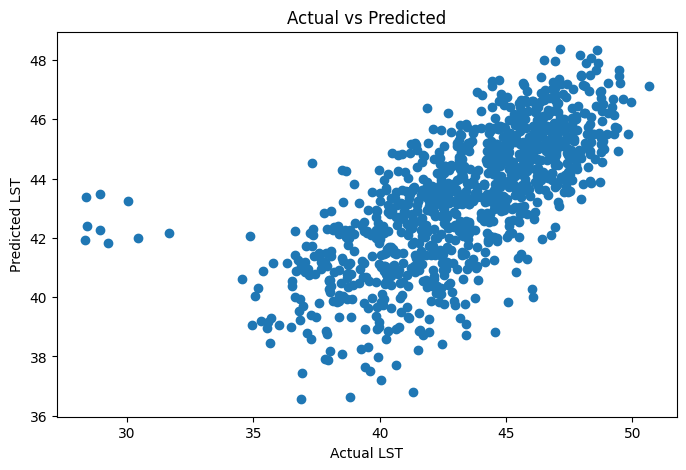

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual LST")
plt.ylabel("Predicted LST")
plt.title("Actual vs Predicted")

plt.show()